<a href="https://colab.research.google.com/github/Ritik4259/Neural-Network-from-scratch/blob/main/Weight_and_bias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

### First neuron

In [ ]:
x = [1,2,3]
w = [0.5,0.7,0.9]
b = 3

output = (w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b)
print(output)

7.6


### First Layer

In [ ]:
x = [1,2,4,3]
w = [[0.5,0.4,0.1,0.9],
     [0.9,0.7,0.2,0.1],
     [0.4,0.1,0.3,0.5]]

w1 = w[0]
w2 = w[1]
w3 = w[2]

b = [2,0.5,3]

b1 = b[0]
b2 = b[1]
b3 = b[2]

output = [
    w1[0]*x[0] + w1[1]*x[1] + w1[2]*x[2] + w1[3]*x[3] + b1,
    w2[0]*x[0] + w2[1]*x[1] + w2[2]*x[2] + w2[3]*x[3] + b2,
    w3[0]*x[0] + w3[1]*x[1] + w3[2]*x[2] + w3[3]*x[3] + b3
]

print(output)

[6.4, 3.8999999999999995, 6.3]


### Using for loop

In [ ]:
layer_output = []
for neuron_weight,neuron_bias in zip(w,b):
    neuron_output = 0
    for nx,nw in zip(x,neuron_weight):
        neuron_output+= nw*nx
    neuron_output+=neuron_bias

    layer_output.append(neuron_output)

print(layer_output)

[6.4, 3.8999999999999995, 6.3]


### Using numpy

In [ ]:
x = [1,2,4,3]
w = [[0.5,0.4,0.1,0.9],
     [0.9,0.7,0.2,0.1],
     [0.4,0.1,0.3,0.5]]

b = [2,0.5,3]

x_ = np.array(x)
w_ = np.array(w)
b_ = np.array(b)

layer_out = np.dot(w_,x_) + b_

print(layer_out)

[6.4 3.9 6.3]


### Layer of neuron with batch of input

In [ ]:
x = [[1,3,5,9],
     [0.5,4,2,6],
     [0.6,7,2,3]
    ]

x_ = np.array(x)

layer_out = np.dot(x_,w_.T) + b_
print(layer_out)

[[12.3   5.4   9.7 ]
 [ 9.45  4.75  7.2 ]
 [ 8.    6.64  6.04]]


### 2 layers with batch data

In [ ]:
import numpy as np

inputs = [[1, 2, 3, 2.5],
          [2., 5., -1., 2],
          [-1.5, 2.7, 3.3, -0.8]]

weights = [[0.2, 0.8, -0.5, 1],
           [0.5, -0.91, 0.26, -0.5],
           [-0.26, -0.27, 0.17, 0.87]]

biases = [2, 3, 0.5]

weights2 = [[0.1, -0.14, 0.5],
            [-0.5, 0.12, -0.33],
            [-0.44, 0.73, -0.13]]

biases2 = [-1, 2, -0.5]

inputs_array = np.array(inputs)
weights_array = np.array(weights)
biases_array = np.array(biases)
weights2_array = np.array(weights2)
biases2_array = np.array(biases2)

layer1_outputs = np.dot(inputs_array, weights_array.T) + biases_array

layer2_outputs = np.dot(layer1_outputs, weights2_array.T) + biases2_array

print(layer2_outputs)


[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


### Generating non-linear data

In [ ]:
!pip install nnfs

In [ ]:
import nnfs
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt

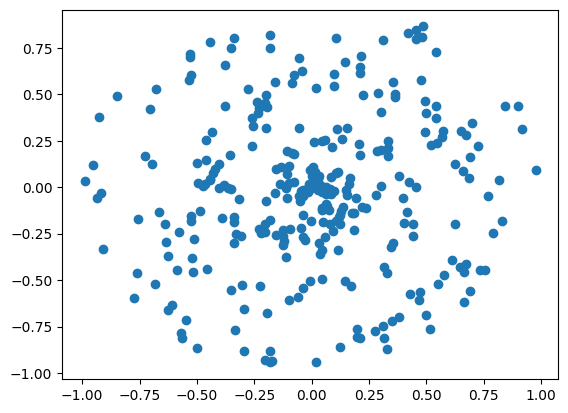

In [ ]:
X,y = spiral_data(samples=100,classes=3)
plt.scatter(X[:,0],X[:,1])
plt.show()

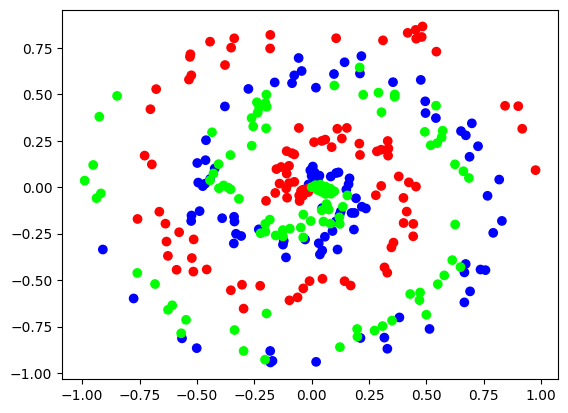

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg')
plt.show()

### Weight and Bias Initialization

#### Using random.randn()

In [ ]:
n_input = 3
n_neurons = 4
w = np.random.randn(n_neurons,n_input)*0.01
b = np.zeros((n_neurons,1))

print(w,"\n\n",b)

[[-0.01200281 -0.01130912 -0.00946417]
 [ 0.00094212  0.00073268 -0.00322949]
 [ 0.00516614  0.02983593 -0.01069083]
 [-0.00857022 -0.0084507  -0.0165881 ]] 

 [[0.]
 [0.]
 [0.]
 [0.]]


#### Using Xavier Initialization (for sigmoid/tanh)

In [ ]:
w = np.random.randn(n_neurons, n_input) * np.sqrt(1 / n_input)
w

array([[-0.3045819 , -0.64755358, -0.24223214],
       [ 0.33115568,  0.51406665,  0.19844353],
       [ 0.02811563,  0.14777227, -1.36355679],
       [-0.42196845, -0.05707173, -0.78597472]])

#### Using He Initialization (for ReLU)

In [ ]:
w = np.random.randn(n_neurons, n_input) * np.sqrt(2 / n_input)
w

array([[-0.45898605,  0.14615665,  0.45984578],
       [ 0.23374502,  0.23113479, -0.30989692],
       [-0.21697872,  0.91906233,  0.66361882],
       [-0.99347728,  0.02670106, -0.42951174]])

### Dense layer

In [ ]:
class dense_layer:
    def __init__(self,n_input,n_neurons):
        self.weight = np.random.randn(n_input,n_neurons) * np.sqrt(2 / n_input)
        self.bias = np.zeros((1,n_neurons))

    def forward(self,inputs):
        self.output = np.dot(inputs,self.weight) + self.bias

In [ ]:
n_input = 2
n_neurons = 3
X,y = spiral_data(samples=100,classes=3)
dense1 = dense_layer(n_input,n_neurons)

dense1.forward(X)

print(dense1.output[:5])

[[ 0.          0.          0.        ]
 [ 0.00717999 -0.01701415 -0.02137199]
 [ 0.01306326 -0.03436108 -0.04239699]
 [ 0.03364522 -0.03039526 -0.04926236]
 [ 0.02883489 -0.06801764 -0.08550898]]


In [ ]:
batch_size = 100
n_input = 3
n_neuron = 4

X = np.random.randn(batch_size,n_input)
dense2 = dense_layer(n_input,n_neuron)

dense2.forward(X)

print(dense2.output[:5])

[[ 0.89478921 -2.05703419 -2.27984157 -1.03630539]
 [-0.57903349  0.85002098  1.19637207  0.80791566]
 [-0.06853467 -1.17030692 -1.0922695  -0.78318259]
 [ 2.23145014 -0.00936015 -0.84073729  0.64039113]
 [ 0.69724441  1.58681515  1.0133233   0.63144382]]


### Activation Layer

#### ReLu

In [ ]:
class activation_relu:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs)

In [ ]:
relu_layer1 = activation_relu()
relu_layer1.forward(dense2.output)
relu_layer1.output[:5]

array([[0.89478921, 0.        , 0.        , 0.        ],
       [0.        , 0.85002098, 1.19637207, 0.80791566],
       [0.        , 0.        , 0.        , 0.        ],
       [2.23145014, 0.        , 0.        , 0.64039113],
       [0.69724441, 1.58681515, 1.0133233 , 0.63144382]])

#### Softmax

In [ ]:
class Activation_softmax:
    def forward(self,inputs):
        exp_vals = np.exp(inputs - np.max(inputs,axis=1,keepdims=True))
        prob = exp_vals/np.sum(exp_vals,axis=1,keepdims=True)
        self.output = prob

In [ ]:
softmax_layer = Activation_softmax()
softmax_layer.forward(relu_layer1.output)
softmax_layer.output[:5]

array([[0.44921991, 0.18359336, 0.18359336, 0.18359336],
       [0.11247307, 0.26315279, 0.37207145, 0.25230268],
       [0.25      , 0.25      , 0.25      , 0.25      ],
       [0.70499241, 0.07569688, 0.07569688, 0.14361384],
       [0.17415108, 0.42389846, 0.23888974, 0.16306072]])

## Complete network

In [ ]:
n_batch = 100
n_input = 4
n_neuron = 3

X = np.random.randn(n_batch,n_input)

dense1 = dense_layer(n_input,n_neuron)
activation1 = activation_relu()

dense2 = dense_layer(n_neuron,4)
activation2 = Activation_softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])


[[0.03515448 0.07081172 0.73580542 0.15822837]
 [0.18219048 0.15901293 0.09221057 0.56658602]
 [0.3018223  0.15645914 0.1136708  0.42804777]
 [0.29102073 0.19831101 0.39934534 0.11132293]
 [0.05359591 0.05260167 0.83062467 0.06317775]]


In [ ]:
np.sum(activation2.output[:5],axis=1)

array([1., 1., 1., 1., 1.])

### Cross entropy loss

In [ ]:
softmax_output = np.array([
    [0.7,0.1,0.2],
    [0.1,0.5,0.4],
    [0.02,0.9,0.08]
])

class_target = [0,1,1]

print(softmax_output[range(len(softmax_output)),class_target])

[0.7 0.5 0.9]


In [ ]:
range(len(softmax_output))

range(0, 3)

In [ ]:
print(-np.log(softmax_output[range(len(softmax_output)),class_target]))

neg_loss = -np.log(softmax_output[range(len(softmax_output)),class_target])

average_loss = np.mean(neg_loss)
average_loss

[0.35667494 0.69314718 0.10536052]


np.float64(0.38506088005216804)

#### If data is one hot encoded

In [ ]:
y_true_check = np.array([
    [1,0,0],
    [0,1,0],
    [0,1,0]
])

y_pred = np.array([
    [0.7,0.1,0.2],
    [0.1,0.5,0.4],
    [0.02,0.9,0.08]
])

A = y_true_check*y_pred
B = np.sum(A,axis=1)

C = -np.log(B)

print(A)
print(B)
print(C)

print(C.mean())


[[0.7 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.9 0. ]]
[0.7 0.5 0.9]
[0.35667494 0.69314718 0.10536052]
0.38506088005216804


### Loss Class

In [ ]:
class Loss:
    def calculate(self,output,y):
        sample_loss = self.forward(output,y)
        data_loss = np.mean(sample_loss)
        return data_loss

In [ ]:
class Loss_Cat_Cross_Entropy(Loss):
    def forward(self,y_pred,y_true):
        samples = len(y_pred)
        y_pred_clip = np.clip(y_pred,1e-7,1-1e-7)

        if len(y_true.shape)==1:
            result = y_pred_clip[range(samples),y_true]
        elif len(y_true.shape)==2:
            result = y_pred_clip*y_true
            result = np.sum(result,axis=1)

        neg_log_likelihood = -np.log(result)
        return neg_log_likelihood

In [ ]:
softmax_output = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
class_target = np.array([[1, 0, 0],
 [0, 1, 0],
 [0, 1, 0]])
loss_func = Loss_Cat_Cross_Entropy()
loss = loss_func.calculate(softmax_output,class_target)
print(loss)

0.38506088005216804


### Code till now

In [ ]:
X,y = spiral_data(samples=100,classes=3)

dense1 = dense_layer(2,3)
activation1 = activation_relu()

dens2 = dense_layer(3,3)
activation2 = Activation_softmax()

loss_func = Loss_Cat_Cross_Entropy()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

loss = loss_func.calculate(activation2.output,y)

print(f"\nLoss: {loss}")

[[0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]
 [0.24985316 0.24994073 0.25026489 0.24994122]
 [0.25       0.25       0.25       0.25      ]
 [0.25       0.25       0.25       0.25      ]]

Loss: 1.6606122160052692


### Accuracy

In [ ]:
softmax_output = softmax_output = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
class_target = np.array([[1, 0, 0],
 [0, 1, 0],
 [0, 1, 0]])

prediction = np.argmax(softmax_output,axis=1)
print(prediction)

if len(class_target.shape)==2:
    class_target = np.argmax(class_target,axis=1)

print(class_target)
accuracy = np.mean(prediction==class_target)

print(accuracy)

[0 1 1]
[0 1 1]
1.0


In [ ]:
prediction

array([0, 1, 1])

In [ ]:
class_target

array([0, 1, 1])

## Optimization

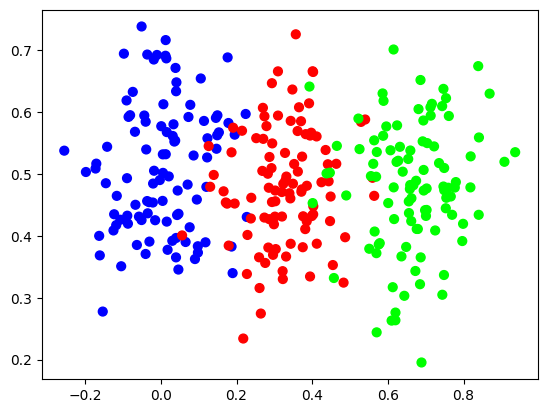

In [ ]:
from nnfs.datasets import vertical_data
nnfs.init()

X,y = vertical_data(samples=100,classes=3)
plt.scatter(X[:,0],X[:,1],c=y,s=40,cmap='brg')
plt.show()

### Strategy 1 : Randomly select weights and biases

In [ ]:
dense1 = dense_layer(2,3)
activation1 = activation_relu()

dens2 = dense_layer(3,3)
activation2 = Activation_softmax()

loss_function = Loss_Cat_Cross_Entropy()

lowest_loss = 9999999

best_dense1_weight = dense1.weight.copy()
best_dense2_weight = dense2.weight.copy()
best_dense1_bias = dense1.bias.copy()
best_dense2_bias = dense2.bias.copy()

for iteration in range(1000000):
  dense1.weight = 0.05*np.random.randn(2,3)
  dense1.bias = 0.05*np.random.randn(1,3)
  dense2.weight = 0.05*np.random.randn(3,3)
  dense2.bias = 0.05*np.random.randn(1,3)

  dense1.forward(X)
  activation1.forward(dense1.output)
  dense2.forward(activation1.output)
  activation2.forward(dense2.output)

  loss = loss_function.calculate(activation2.output,y)

  prediction = np.argmax(activation2.output,axis=1)
  accuracy = np.mean(prediction==y)

  if loss < lowest_loss:
    lowest_loss = loss
    print(f"New set of weights found, iteration: {iteration}, loss: {loss}, accuracy: {accuracy}")
    best_dense1_weight = dense1.weight.copy()
    best_dense1_bias = dense1.bias.copy()
    best_dense2_weight = dense2.weight.copy()
    best_dense2_bias = dense2.bias.copy()


New set of weights found, iteration: 0, loss: 1.1004003286361694, accuracy: 0.3333333333333333
New set of weights found, iteration: 2, loss: 1.098616123199463, accuracy: 0.3333333333333333
New set of weights found, iteration: 12, loss: 1.0985645055770874, accuracy: 0.3333333333333333
New set of weights found, iteration: 14, loss: 1.0978987216949463, accuracy: 0.3333333333333333
New set of weights found, iteration: 20, loss: 1.0973840951919556, accuracy: 0.3333333333333333
New set of weights found, iteration: 236, loss: 1.0965837240219116, accuracy: 0.3333333333333333
New set of weights found, iteration: 3199, loss: 1.0965325832366943, accuracy: 0.6133333333333333
New set of weights found, iteration: 3415, loss: 1.0964535474777222, accuracy: 0.3333333333333333
New set of weights found, iteration: 4902, loss: 1.0964208841323853, accuracy: 0.3333333333333333
New set of weights found, iteration: 5704, loss: 1.0962671041488647, accuracy: 0.3333333333333333
New set of weights found, iteratio

### Strategy 2 : Randomly adjust weights and biases

In [ ]:
dense1 = dense_layer(2,3)
activation1 = activation_relu()

dens2 = dense_layer(3,3)
activation2 = Activation_softmax()

loss_function = Loss_Cat_Cross_Entropy()

lowest_loss = 9999999

best_dense1_weight = dense1.weight.copy()
best_dense2_weight = dense2.weight.copy()
best_dense1_bias = dense1.bias.copy()
best_dense2_bias = dense2.bias.copy()

for iteration in range(100000):
  dense1.weight += 0.05*np.random.randn(2,3)
  dense1.bias += 0.05*np.random.randn(1,3)
  dense2.weight += 0.05*np.random.randn(3,3)
  dense2.bias += 0.05*np.random.randn(1,3)

  dense1.forward(X)
  activation1.forward(dense1.output)
  dense2.forward(activation1.output)
  activation2.forward(dense2.output)

  loss = loss_function.calculate(activation2.output,y)

  prediction = np.argmax(activation2.output,axis=1)
  accuracy = np.mean(prediction==y)

  if loss < lowest_loss:
    lowest_loss = loss
    print(f"New set of weights found, iteration: {iteration}, loss: {loss}, accuracy: {accuracy}")
    best_dense1_weight = dense1.weight.copy()
    best_dense1_bias = dense1.bias.copy()
    best_dense2_weight = dense2.weight.copy()
    best_dense2_bias = dense2.bias.copy()
  else:
    dense1.weight = best_dense1_weight.copy()
    dense1.bias = best_dense1_bias.copy()
    dense2.weight = best_dense2_weight.copy()
    dense2.bias = best_dense1_bias.copy()


New set of weights found, iteration: 0, loss: 1.0966598987579346, accuracy: 0.3333333333333333
New set of weights found, iteration: 1, loss: 1.0630518198013306, accuracy: 0.33666666666666667
New set of weights found, iteration: 2, loss: 1.0543811321258545, accuracy: 0.3466666666666667
New set of weights found, iteration: 3, loss: 1.0380210876464844, accuracy: 0.36333333333333334
New set of weights found, iteration: 5, loss: 1.0051430463790894, accuracy: 0.3333333333333333
New set of weights found, iteration: 8, loss: 1.0025039911270142, accuracy: 0.3333333333333333
New set of weights found, iteration: 11, loss: 0.9726935029029846, accuracy: 0.35333333333333333
New set of weights found, iteration: 24, loss: 0.9660502076148987, accuracy: 0.3466666666666667
New set of weights found, iteration: 25, loss: 0.9631115794181824, accuracy: 0.34
New set of weights found, iteration: 27, loss: 0.9575372338294983, accuracy: 0.33666666666666667
New set of weights found, iteration: 33, loss: 0.9566463